## Giai đoạn 2: Tiền xử lý dữ liệu (Preprocessing)

- One-Hot Encoding các biến nominal
- Giữ nguyên các biến ordinal
- Chuyển biến binary từ (1, 2) sang (0, 1)
- Xử lý class imbalance
- Train/Test Split 80/20 với `stratify=y`
- Lưu dữ liệu đã xử lý vào `data/processed/`

### Task 1: Tải thư viện và đọc dữ liệu

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# Đọc dữ liệu thô
FILE_PATH = '../data/csv/Raw_Data_DIB.csv'
df = pd.read_csv(FILE_PATH)

# Chuẩn hóa tên cột (xoá khoảng trắng thừa nếu có)
df.columns = df.columns.str.strip()

print(f'✅ Đọc dữ liệu thành công: {df.shape[0]:,} dòng × {df.shape[1]} cột')
display(df.head(3))

✅ Đọc dữ liệu thành công: 1,434 dòng × 25 cột


,Gender,Age code,BMI,Designation,Specialization,Working_Place,Duration,Private_Practice,Working_Hour,Weekly_Vacation,...,Vacation_with_Family,Family_Functions,Disappointing_Thing,Feelings,Conflict,Dissatisfaction,Mental_Disturbances,Politics,Flexibility,Burn Out
0,2,3,3,9,16,1,5,1,1,1,...,1,1,7,6,4,7,9,1,1,4
1,1,2,2,8,16,1,4,1,1,1,...,1,2,1,1,1,5,3,2,1,3
2,1,2,2,8,16,1,4,1,1,1,...,1,2,7,1,1,5,3,2,1,4


### Cell 2 — Khai báo phân nhóm biến

- Phân loại toàn bộ 24 features thành 3 nhóm dựa trên phân tích EDA:

| Nhóm | Ý nghĩa | Xử lý |
|------|---------|-------|
| **Binary** | Chỉ có 2 giá trị (1/2), không có thứ tự | Chuyển sang 0/1 |
| **Ordinal** | Có thứ tự tăng dần rõ ràng | Giữ nguyên |
| **Nominal** | Nhiều nhóm, không có thứ tự | One-Hot Encoding |

In [ ]:
TARGET_COL = 'Burn Out'

# Biến nhị phân (Binary): chỉ có 2 giá trị, không có thứ tự
# Gốc: 1=Có/Nam/..., 2=Không/Nữ/... -> chuyển thành 0/1
BINARY_COLS = [
    'Gender',               # 1=Nam       → 0 | 2=Nữ          → 1
    'Liabilities',          # 1=Có        → 0 | 2=Không       → 1
    'Staying_with_Family',  # 1=Có        → 0 | 2=Không       → 1
    'Politics',             # 1=Lo ngại   → 0 | 2=Không       → 1
    'Flexibility',          # 1=Đồng ý    → 0 | 2=Không đồng ý→ 1
]

# Biến thứ bậc (Ordinal): có thứ tự tăng dần, giữ nguyên
ORDINAL_COLS = [
    'Age code',        # 1=<25  → 2=25–34 → 3=35–44 → 4=45–54 → 5=≥55
    'BMI',             # 1=Gầy  → 2=BT    → 3=Thừa cân → 4=Béo phì
    'Income',          # 1=<20k → ... → 5=>100k
    'Family_members',  # 1=2 người → tăng dần
    'Duration',        # thâm niên công tác tăng dần
    'Working_Hour',    # giờ làm/ngày tăng dần
    'Weekly_Vacation', # ngày nghỉ/tuần
]

# Biến danh nghĩa (Nominal): nhiều nhóm, KHÔNG có thứ tự
# -> cần One-Hot Encoding để tránh mô hình hiểu nhầm thứ tự
NOMINAL_COLS = [
    'Designation',           # chức danh (mã 1–13, không có thứ tự)
    'Specialization',        # chuyên khoa (mã 1–16)
    'Working_Place',         # nơi làm việc
    'Private_Practice',      # hành nghề tư (trong TP / ngoài TP / không)
    'Marital_Status',        # tình trạng hôn nhân
    'Vacation_with_Family',  # đi nghỉ cùng gia đình (thỉnh thoảng/hiếm/không)
    'Family_Functions',      # tham dự sự kiện gia đình
    'Disappointing_Thing',   # điều thất vọng nhất (các loại khác nhau)
    'Feelings',              # cảm xúc khi làm việc với bệnh nhân
    'Conflict',              # xung đột với ai (đồng nghiệp/gia đình/cả hai)
    'Dissatisfaction',       # triệu chứng do bất mãn (lo âu/mệt mỏi/mất ngủ...)
    'Mental_Disturbances',   # cách xử lý stress (nghỉ phép/thuốc/liệu pháp...)
]

# Kiểm tra không bỏ sót cột nào
all_declared = set(BINARY_COLS + ORDINAL_COLS + NOMINAL_COLS + [TARGET_COL])
all_actual   = set(df.columns)
missing = all_actual - all_declared
extra   = all_declared - all_actual

if not missing and not extra:
    print('✅ Phân nhóm biến hợp lệ, tất cả 25 cột đã được khai báo.')
else:
    if missing: print(f'⚠️  Cột chưa được khai báo: {missing}')
    if extra:   print(f'⚠️  Cột khai báo nhưng không tồn tại: {extra}')

print(f'\n   🔵 Binary  : {len(BINARY_COLS):2d} biến → {BINARY_COLS}')
print(f'   🔵 Ordinal : {len(ORDINAL_COLS):2d} biến → {ORDINAL_COLS}')
print(f'   🔵 Nominal : {len(NOMINAL_COLS):2d} biến → {NOMINAL_COLS}')

✅ Phân nhóm biến hợp lệ — tất cả 25 cột đã được khai báo.

   🔵 Binary  :  5 biến → ['Gender', 'Liabilities', 'Staying_with_Family', 'Politics', 'Flexibility']
   🔵 Ordinal :  7 biến → ['Age code', 'BMI', 'Income', 'Family_members', 'Duration', 'Working_Hour', 'Weekly_Vacation']
   🔵 Nominal : 12 biến → ['Designation', 'Specialization', 'Working_Place', 'Private_Practice', 'Marital_Status', 'Vacation_with_Family', 'Family_Functions', 'Disappointing_Thing', 'Feelings', 'Conflict', 'Dissatisfaction', 'Mental_Disturbances']


### Task 3: Chuyển biến binary: (1, 2) → (0, 1)

- Quy tắc đơn giản: **giá trị gốc − 1**. 
- Ví dụ: `Gender` 1=Nam→0, 2=Nữ→1.

In [3]:
df_processed = df.copy()

print('🔄 Chuyển đổi biến binary (1,2) → (0,1):\n')
print(f'  {"Biến":<25} {"Trước":<20} {"Sau"}')
print('  ' + '-' * 60)

for col in BINARY_COLS:
    before = sorted(df_processed[col].unique())
    df_processed[col] = df_processed[col] - 1
    after  = sorted(df_processed[col].unique())
    print(f'  {col:<25} {str(before):<20} {after}')

print('\n✅ Hoàn tất chuyển đổi binary.')

🔄 Chuyển đổi biến binary (1,2) → (0,1):

  Biến                      Trước                Sau
  ------------------------------------------------------------
  Gender                    [np.int64(1), np.int64(2)] [np.int64(0), np.int64(1)]
  Liabilities               [np.int64(1), np.int64(2)] [np.int64(0), np.int64(1)]
  Staying_with_Family       [np.int64(1), np.int64(2)] [np.int64(0), np.int64(1)]
  Politics                  [np.int64(1), np.int64(2)] [np.int64(0), np.int64(1)]
  Flexibility               [np.int64(1), np.int64(2)] [np.int64(0), np.int64(1)]

✅ Hoàn tất chuyển đổi binary.


### Task 4: Kiểm tra biến ordinal

- Các biến ordinal **giữ nguyên giá trị số** vì thứ tự đã có ý nghĩa. 
- Chỉ cần xác nhận range hợp lý và không có giá trị lạ.

In [4]:
print('🔍 Kiểm tra biến ordinal (giữ nguyên):\n')
print(f'  {"Biến":<25} {"Min":<6} {"Max":<6} {"Các giá trị"}')
print('  ' + '-' * 65)

for col in ORDINAL_COLS:
    vals = sorted(df_processed[col].unique())
    print(f'  {col:<25} {min(vals):<6} {max(vals):<6} {vals}')

print('\n✅ Các biến ordinal hợp lệ — không cần chỉnh sửa.')

🔍 Kiểm tra biến ordinal (giữ nguyên):

  Biến                      Min    Max    Các giá trị
  -----------------------------------------------------------------
  Age code                  1      5      [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  BMI                       1      4      [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Income                    1      6      [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  Family_members            1      2      [np.int64(1), np.int64(2)]
  Duration                  1      5      [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Working_Hour              1      6      [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  Weekly_Vacation           1      2      [np.int64(1), np.int64(2)]

✅ Các biến ordinal hợp lệ — không cần chỉnh sửa.


### Tssk 5: One-Hot Encoding biến nominal

- Mỗi giá trị trong biến nominal được tách thành **một cột riêng** (0/1). 
- Dùng `drop='first'` để tránh **dummy variable trap** (đa cộng tuyến) - Xảy ra khi các biến độc lập (các biến đầu vào) có mối quan hệ rất chặt chẽ với nhau.

> **Ví dụ:** `Conflict` có 3 giá trị (1/2/3) → tạo 2 cột mới: `Conflict_2`, `Conflict_3`. 
> Khi cả 2 đều = 0 thì ngầm hiểu là giá trị 1 (nhóm tham chiếu).

In [6]:
print('🔄 Thực hiện One-Hot Encoding cho biến nominal...\n')
print(f'  {"Biến":<25} {"Số giá trị gốc":<20} {"Số cột mới tạo"}')
print('  ' + '-' * 60)

ohe_frames = []

for col in NOMINAL_COLS:
    n_unique = df_processed[col].nunique()
    dummies = pd.get_dummies(
        df_processed[col],
        prefix=col,
        drop_first=True,     # Bỏ cột đầu tiên để tránh đa cộng tuyến
        dtype=int
    )
    n_new = dummies.shape[1]
    print(f'  {col:<25} {n_unique:<20} {n_new} cột')
    ohe_frames.append(dummies)

# Ghép lại: ordinal + binary (đã xử lý) + OHE nominal + target
df_encoded = pd.concat(
    [df_processed[ORDINAL_COLS],
     df_processed[BINARY_COLS],
     pd.concat(ohe_frames, axis=1),
     df_processed[[TARGET_COL]]],
    axis=1
)

n_features_before = len(df.columns) - 1
n_features_after  = df_encoded.shape[1] - 1

print(f'\n📊 Kết quả:')
print(f'   🔵 Số features trước OHE : {n_features_before}')
print(f'   🔵 Số features sau  OHE  : {n_features_after} (+{n_features_after - n_features_before} cột mới)')
print(f'   🔵 Kích thước dataset    : {df_encoded.shape}')
print(f'\n✅ One-Hot Encoding hoàn tất.')
display(df_encoded.head(3))

🔄 Thực hiện One-Hot Encoding cho biến nominal...

  Biến                      Số giá trị gốc       Số cột mới tạo
  ------------------------------------------------------------
  Designation               12                   11 cột
  Specialization            21                   20 cột
  Working_Place             3                    2 cột
  Private_Practice          4                    3 cột
  Marital_Status            4                    3 cột
  Vacation_with_Family      3                    2 cột
  Family_Functions          3                    2 cột
  Disappointing_Thing       9                    8 cột
  Feelings                  6                    5 cột
  Conflict                  4                    3 cột
  Dissatisfaction           8                    7 cột
  Mental_Disturbances       9                    8 cột

📊 Kết quả:
   🔵 Số features trước OHE : 24
   🔵 Số features sau  OHE  : 86 (+62 cột mới)
   🔵 Kích thước dataset    : (1434, 87)

✅ One-Hot Encoding hoàn tất.


,Age code,BMI,Income,Family_members,Duration,Working_Hour,Weekly_Vacation,Gender,Liabilities,Staying_with_Family,...,Dissatisfaction_8,Mental_Disturbances_2,Mental_Disturbances_3,Mental_Disturbances_4,Mental_Disturbances_5,Mental_Disturbances_6,Mental_Disturbances_7,Mental_Disturbances_8,Mental_Disturbances_9,Burn Out
0,3,3,5,1,5,1,1,1,1,0,...,0,0,0,0,0,0,0,0,1,4
1,2,2,4,1,4,1,1,0,0,0,...,0,0,1,0,0,0,0,0,0,3
2,2,2,4,1,4,1,1,0,0,0,...,0,0,1,0,0,0,0,0,0,4


### Task 6: Kiểm tra class imbalance

- Trước khi chia train/test, cần biết các lớp có cân bằng không để quyết định chiến lược xử lý.

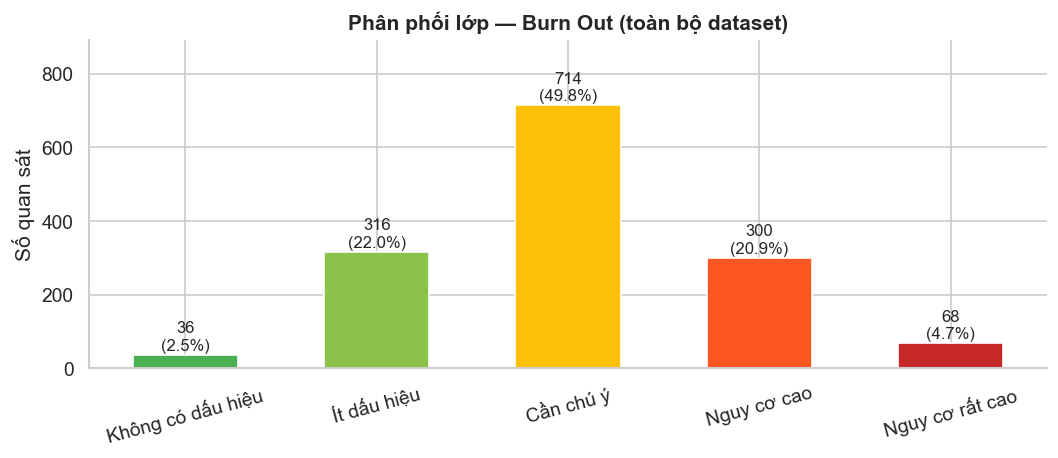


📊 Tóm tắt class imbalance:
   🔵 Lớp chiếm nhiều nhất : 49.8%
   🔵 Lớp chiếm ít nhất    : 2.5%
   🔵 Tỷ lệ lớp lớn/nhỏ   : 19.8x

⚠️  Mất cân bằng NGHIÊM TRỌNG (≥5x).
  -> Khuyến nghị: dùng class_weight="balanced" + cân nhắc SMOTE.


In [8]:
BURNOUT_LABEL = {
    1: 'Không có dấu hiệu',
    2: 'Ít dấu hiệu',
    3: 'Cần chú ý',
    4: 'Nguy cơ cao',
    5: 'Nguy cơ rất cao',
}
BURNOUT_COLOR = {
    1: '#4CAF50', 2: '#8BC34A', 3: '#FFC107', 4: '#FF5722', 5: '#C62828'
}

y_full   = df_encoded[TARGET_COL]
counts   = y_full.value_counts().sort_index()
pct      = (counts / counts.sum() * 100).round(1)
labels   = [BURNOUT_LABEL.get(k, str(k)) for k in counts.index]
colors   = [BURNOUT_COLOR.get(k, '#888') for k in counts.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, counts.values, color=colors, width=0.55, edgecolor='white')
for bar, n, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{n:,}\n({p}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Phân phối lớp — Burn Out (toàn bộ dataset)', fontweight='bold')
ax.set_ylabel('Số quan sát')
ax.set_ylim(0, counts.max() * 1.25)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/11_class_distribution.png', bbox_inches='tight')
plt.show()

# Đánh giá mức độ mất cân bằng
max_pct = pct.max()
min_pct = pct.min()
ratio   = counts.max() / counts.min()

print(f'\n📊 Tóm tắt class imbalance:')
print(f'   🔵 Lớp chiếm nhiều nhất : {max_pct}%')
print(f'   🔵 Lớp chiếm ít nhất    : {min_pct}%')
print(f'   🔵 Tỷ lệ lớp lớn/nhỏ   : {ratio:.1f}x')

print()
if ratio >= 5:
    print('⚠️  Mất cân bằng NGHIÊM TRỌNG (≥5x).')
    print('  -> Khuyến nghị: dùng class_weight="balanced" + cân nhắc SMOTE.')
elif ratio >= 2:
    print('⚠️  Mất cân bằng VỪA PHẢI (2–5x).')
    print(' -> Khuyến nghị: dùng class_weight="balanced" trong Random Forest.')
else:
    print('✅ Phân phối tương đối cân bằng — không cần xử lý đặc biệt.')

### Task 7: Quyết định chiến lược xử lý class imbalance

- Hai lựa chọn phổ biến:

| Phương pháp | Cách hoạt động | Khi nào dùng |
|-------------|---------------|---------------|
| `class_weight='balanced'` | Phạt nặng hơn khi sai lớp thiểu số | Luôn nên bật, đơn giản, không tạo dữ liệu giả |
| SMOTE | Tạo thêm mẫu giả cho lớp thiểu số | Khi tỷ lệ ≥ 5x và class_weight chưa đủ |

> Với bộ dữ liệu này, **bắt đầu bằng `class_weight='balanced'`** (sẽ truyền vào Random Forest ở notebook 03).

In [11]:
#  Tính class_weight thủ công để minh hoạ
n_samples  = len(y_full)
n_classes  = y_full.nunique()
class_w    = {}
for cls, cnt in counts.items():
    class_w[cls] = round(n_samples / (n_classes * cnt), 4)

print('📐 Class weight tương đương class_weight="balanced" trong sklearn:')
print(f'   🔵 Công thức: n_samples / (n_classes × count_per_class)')
print(f'   🔵 n_samples  = {n_samples:,}')
print(f'   🔵 n_classes  = {n_classes}')
print()
for cls, w in class_w.items():
    lbl = BURNOUT_LABEL.get(cls, str(cls))
    print(f'🟠 Lớp {cls} ({lbl:<22}): count={counts[cls]:>4}, weight={w}')

print()
print('💡 Lớp có ít mẫu hơn sẽ được gán trọng số cao hơn')
print(' 📣 Random Forest sẽ "chú ý" hơn đến các lớp thiểu số.')
print()
print('✅ Chiến lược đã chọn: class_weight="balanced" (truyền vào notebook 03)')

📐 Class weight tương đương class_weight="balanced" trong sklearn:
   🔵 Công thức: n_samples / (n_classes × count_per_class)
   🔵 n_samples  = 1,434
   🔵 n_classes  = 5

🟠 Lớp 1 (Không có dấu hiệu     ): count=  36, weight=7.9667
🟠 Lớp 2 (Ít dấu hiệu           ): count= 316, weight=0.9076
🟠 Lớp 3 (Cần chú ý             ): count= 714, weight=0.4017
🟠 Lớp 4 (Nguy cơ cao           ): count= 300, weight=0.956
🟠 Lớp 5 (Nguy cơ rất cao       ): count=  68, weight=4.2176

💡 Lớp có ít mẫu hơn sẽ được gán trọng số cao hơn
 📣 Random Forest sẽ "chú ý" hơn đến các lớp thiểu số.

✅ Chiến lược đã chọn: class_weight="balanced" (truyền vào notebook 03)


### Task 8: Train/Test Split 80/20 với stratify

- `stratify=y` đảm bảo **tỷ lệ mỗi lớp Burn Out trong tập train và test giống nhau** với toàn bộ dataset.
- Tránh tình trạng một lớp chỉ xuất hiện ở train mà không có ở test.

✅ Train/Test Split hoàn tất:

   🔵 Tổng mẫu  : 1,434
   🔵 Train set : 1,147 mẫu (80%)
   🔵 Test set  : 287  mẫu (20%)
   🔵 Số features: 86


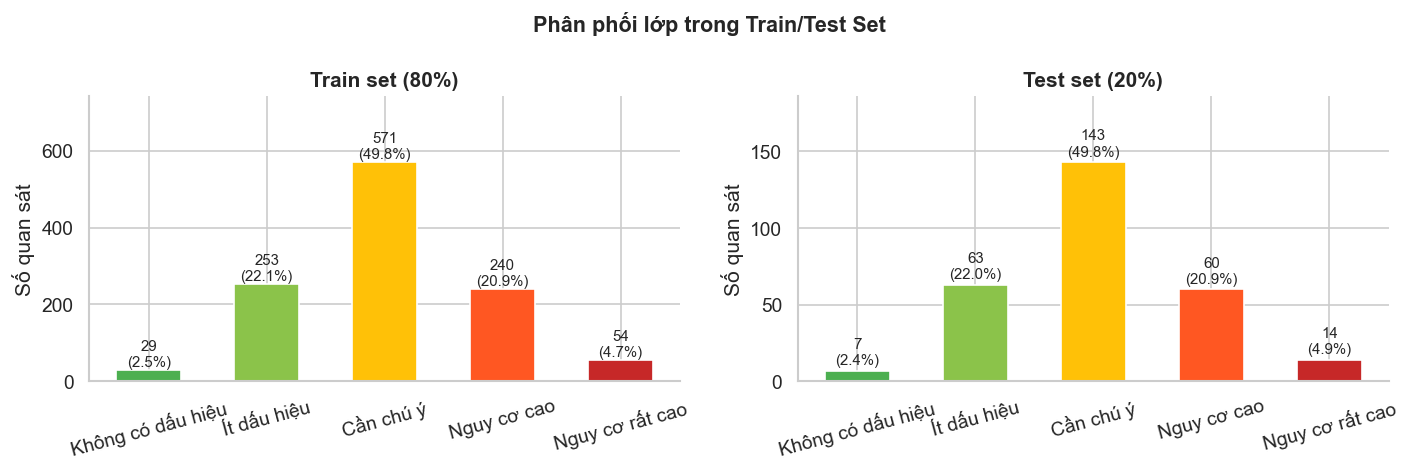


📊 So sánh tỷ lệ lớp giữa các tập:


,Lớp Burn Out,Toàn bộ (%),Train (%),Test (%)
0,Không có dấu hiệu,2.5,2.5,2.4
1,Ít dấu hiệu,22.0,22.1,22.0
2,Cần chú ý,49.8,49.8,49.8
3,Nguy cơ cao,20.9,20.9,20.9
4,Nguy cơ rất cao,4.7,4.7,4.9


In [13]:
X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Giữ tỷ lệ lớp nhất quán
)

print('✅ Train/Test Split hoàn tất:\n')
print(f'   🔵 Tổng mẫu  : {len(X):,}')
print(f'   🔵 Train set : {len(X_train):,} mẫu ({len(X_train)/len(X)*100:.0f}%)')
print(f'   🔵 Test set  : {len(X_test):,}  mẫu ({len(X_test)/len(X)*100:.0f}%)')
print(f'   🔵 Số features: {X_train.shape[1]}')

# Kiểm tra tỷ lệ lớp trong train và test
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (y_split, title) in zip(axes, [(y_train, 'Train set (80%)'), (y_test, 'Test set (20%)')]):
    cnt   = y_split.value_counts().sort_index()
    pct_s = (cnt / cnt.sum() * 100).round(1)
    lbls  = [BURNOUT_LABEL.get(k, str(k)) for k in cnt.index]
    clrs  = [BURNOUT_COLOR.get(k, '#888') for k in cnt.index]
    bars  = ax.bar(lbls, cnt.values, color=clrs, width=0.55, edgecolor='white')
    for bar, n, p in zip(bars, cnt.values, pct_s.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{n}\n({p}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Số quan sát')
    ax.set_ylim(0, cnt.max() * 1.3)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Phân phối lớp trong Train/Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/12_train_test_distribution.png', bbox_inches='tight')
plt.show()

# Bảng so sánh tỷ lệ
compare = pd.DataFrame({
    'Lớp Burn Out': [BURNOUT_LABEL.get(k, str(k)) for k in counts.index],
    'Toàn bộ (%)' : (counts / counts.sum() * 100).round(1).values,
    'Train (%)'   : [(y_train == k).sum() / len(y_train) * 100 for k in counts.index],
    'Test (%)'    : [(y_test  == k).sum() / len(y_test)  * 100 for k in counts.index],
})
compare[['Train (%)', 'Test (%)']] = compare[['Train (%)', 'Test (%)']].round(1)
print('\n📊 So sánh tỷ lệ lớp giữa các tập:')
display(compare)

### Task 9: Lưu dữ liệu đã xử lý

- Lưu toàn bộ dataset đã encode và 4 tập train/test vào `data/processed/` để notebook 03 có thể đọc trực tiếp mà không cần xử lý lại.

In [15]:
import os

PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Lưu dataset đã encode đầy đủ
df_encoded.to_csv(f'{PROCESSED_DIR}/data_encoded.csv', index=False)

# Lưu 4 tập train/test
X_train.to_csv(f'{PROCESSED_DIR}/X_train.csv', index=False)
X_test.to_csv( f'{PROCESSED_DIR}/X_test.csv',  index=False)
y_train.to_csv(f'{PROCESSED_DIR}/y_train.csv', index=False, header=True)
y_test.to_csv( f'{PROCESSED_DIR}/y_test.csv',  index=False, header=True)

# Lưu danh sách tên cột feature
feature_names = pd.Series(X_train.columns, name='feature')
feature_names.to_csv(f'{PROCESSED_DIR}/feature_names.csv', index=False)

print('✅ Đã lưu vào thư mục data/processed/:\n')
for fname in sorted(os.listdir(PROCESSED_DIR)):
    fpath = os.path.join(PROCESSED_DIR, fname)
    fsize = os.path.getsize(fpath)
    print(f'   {fname:<30} {fsize:>10,} bytes')

print(f'\n   💾 Tổng số file: {len(os.listdir(PROCESSED_DIR))}')

✅ Đã lưu vào thư mục data/processed/:

   X_test.csv                         51,084 bytes
   X_train.csv                       199,864 bytes
   data_encoded.csv                  252,392 bytes
   feature_names.csv                   1,527 bytes
   y_test.csv                            871 bytes
   y_train.csv                         3,451 bytes

   💾 Tổng số file: 6


### Task 10: Tổng kết tiền xử lý

- Xác nhận toàn bộ checklist đã hoàn thành và ghi lại thông tin cho notebook 03.

In [17]:
print('=' * 62)
print('       TỔNG KẾT TIỀN XỬ LÝ DỮ LIỆU')
print('=' * 62)
print(f"""
✅ [1] One-Hot Encoding biến nominal
       {len(NOMINAL_COLS)} biến → {n_features_after - len(ORDINAL_COLS) - len(BINARY_COLS)} cột OHE

✅ [2] Biến ordinal giữ nguyên
       {ORDINAL_COLS}

✅ [3] Biến binary chuyển (1,2) → (0,1)
       {BINARY_COLS}

✅ [4] Xử lý class imbalance
       Chiến lược: class_weight='balanced' trong Random Forest
       (Nếu ratio ≥ 5x: bổ sung SMOTE ở notebook 03)

✅ [5] Train/Test Split
       Train : {len(X_train):,} mẫu (80%) | Test : {len(X_test):,} mẫu (20%)
       stratify=y ✓  |  random_state=42 ✓

✅ [6] Lưu file
       data/processed/data_encoded.csv
       data/processed/X_train.csv, X_test.csv
       data/processed/y_train.csv, y_test.csv
       data/processed/feature_names.csv
""")

       TỔNG KẾT TIỀN XỬ LÝ DỮ LIỆU

✅ [1] One-Hot Encoding biến nominal
       12 biến → 74 cột OHE

✅ [2] Biến ordinal giữ nguyên
       ['Age code', 'BMI', 'Income', 'Family_members', 'Duration', 'Working_Hour', 'Weekly_Vacation']

✅ [3] Biến binary chuyển (1,2) → (0,1)
       ['Gender', 'Liabilities', 'Staying_with_Family', 'Politics', 'Flexibility']

✅ [4] Xử lý class imbalance
       Chiến lược: class_weight='balanced' trong Random Forest
       (Nếu ratio ≥ 5x: bổ sung SMOTE ở notebook 03)

✅ [5] Train/Test Split
       Train : 1,147 mẫu (80%) | Test : 287 mẫu (20%)
       stratify=y ✓  |  random_state=42 ✓

✅ [6] Lưu file
       data/processed/data_encoded.csv
       data/processed/X_train.csv, X_test.csv
       data/processed/y_train.csv, y_test.csv
       data/processed/feature_names.csv

